<a href="https://colab.research.google.com/github/HugoCrainich/econ3916-final-project/blob/main/3916_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [8]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can monthly temperature and precipitation data predict the age adjusted suicide rate of a U.S. county?

**This is a prediction (umbrella) problem because:** we are trying to figure out if we can predict suicide rates in areas based on data, not just to see if certain characteristics correlate or effect suicide rates in anyway.

**The decision this enables:** Mainly the suicide prevention groups and organizations that want to devote a certain amount of resources to different areas, using already predictable tempurature and climate data we can predict what areas will be most affected and where to put the most resources (crisis hotline, outreach, therapy).

**Dataset:** U.S. County-Level Suicide Rates with Climate Data (1968–2004)
- **Source:** Github (URL: https://github.com/sheftneal/NCC2018/blob/master/inputs/SuicideData_US.csv)
- **N =** 851,088 observations/rows
- **Features =** 13 total features, usable predictors are: mean monthly temperature, monthly precipitation, population, month, and MAYBE location
- **Target variable =** rate_adj (age-adjusted suicide rate per 100,000)
- **Access date:** April 17th, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [9]:
# ============================================================
# 2.1 Load your dataset
# ============================================================

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Suicide Data_US.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Saving Suicide Data_US.csv to Suicide Data_US (1).csv
Shape: (851088, 13)
Columns: ['fips', 'year', 'month', 'rate_adj', 'count', 'pop', 'tmean', 'prec', 'fipsmo', 'popw', 'yr', 'state', 'stateyear']


,fips,year,month,rate_adj,count,pop,tmean,prec,fipsmo,popw,yr,state,stateyear
0,1001,1968,1,0.000000,0,23315,6.7486,101.4699,1,29860.24,1968.0,1,196801
1,1001,1968,2,0.000000,0,23315,5.4708,54.7664,2,29860.24,1968.0,1,196801
2,1001,1968,3,0.000000,0,23315,12.0775,78.2593,3,29860.24,1968.0,1,196801
3,1001,1968,4,0.000000,0,23315,18.3653,156.2035,4,29860.24,1968.0,1,196801
4,1001,1968,5,4.289084,1,23315,21.3934,64.0978,5,29860.24,1968.0,1,196801


### 2.2 Basic Description

In [10]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851088 entries, 0 to 851087
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   fips       851088 non-null  int64  
 1   year       851088 non-null  int64  
 2   month      851088 non-null  int64  
 3   rate_adj   851088 non-null  float64
 4   count      851088 non-null  int64  
 5   pop        851088 non-null  int64  
 6   tmean      851088 non-null  float64
 7   prec       851088 non-null  float64
 8   fipsmo     851088 non-null  int64  
 9   popw       851088 non-null  float64
 10  yr         851088 non-null  float64
 11  state      851088 non-null  int64  
 12  stateyear  851088 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 84.4 MB


,fips,year,month,rate_adj,count,pop,tmean,prec,fipsmo,popw,yr,state,stateyear
count,851088.000000,851088.000000,851088.000000,851088.000000,851088.000000,8.510880e+05,851088.000000,851088.000000,851088.000000,8.510880e+05,851088.000000,851088.000000,851088.000000
mean,30199.630746,1979.969672,6.500000,1.034362,1.017482,1.064830e+05,12.361432,77.107673,18270.576815,1.064830e+05,1979.969672,30.099825,198027.067001
std,14890.266447,8.192017,3.452055,3.409446,3.300540,3.207862e+05,9.984433,57.844238,10677.800862,3.169341e+05,8.192017,14.873106,819.326822
min,1001.000000,1968.000000,1.000000,0.000000,0.000000,0.000000e+00,-25.070000,0.000000,1.000000,9.272727e+01,1968.000000,1.000000,196801.000000
25%,18165.000000,1973.000000,3.750000,0.000000,0.000000,1.111575e+04,5.120000,33.580275,8919.000000,1.111871e+04,1973.000000,18.000000,197348.000000
50%,29155.000000,1979.000000,6.500000,0.000000,0.000000,2.462100e+04,13.330000,67.080000,18300.000000,2.471129e+04,1979.000000,29.000000,197947.000000
75%,42127.000000,1985.000000,9.250000,0.905559,1.000000,7.769850e+04,20.690000,107.668350,27263.000000,8.010414e+04,1985.000000,42.000000,198537.000000
max,56045.000000,2004.000000,12.000000,229.095100,141.000000,9.639044e+06,35.210000,1103.911000,37296.000000,8.346159e+06,2004.000000,56.000000,200455.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


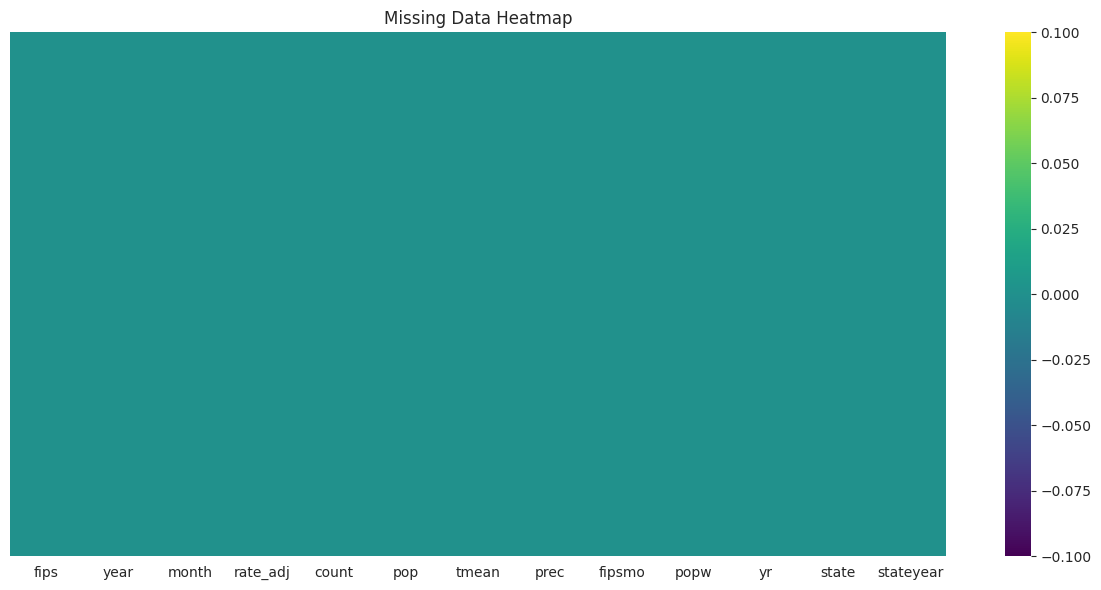

In [11]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

### Missing Data Assessment
The heatmap shows no missing values across all 851,088 rows. This is expected.
The dataset is replication data from a peer reviewed paper (Burke et al. 2018)
and was cleaned prior to publication. No imputation strategy is required.

By the MCAR/MAR/MNAR framework, missingness is not applicable here.
However, a meaningful form of "structural zeros" exists: counties with very
small populations frequently have `rate_adj = 0` not because suicides didn't
occur, but because counts were suppressed by the CDC for privacy reasons
(fewer than 10 events). This is closer to MNAR and will be addressed in
the data quality summary.

**Missing data strategy:** MNAR. ~74% of `rate_adj` values are structural zeros from CDC privacy suppression, not true nulls. Strategy: filter to non zero rows for modeling.


### 2.4 Distribution Plots

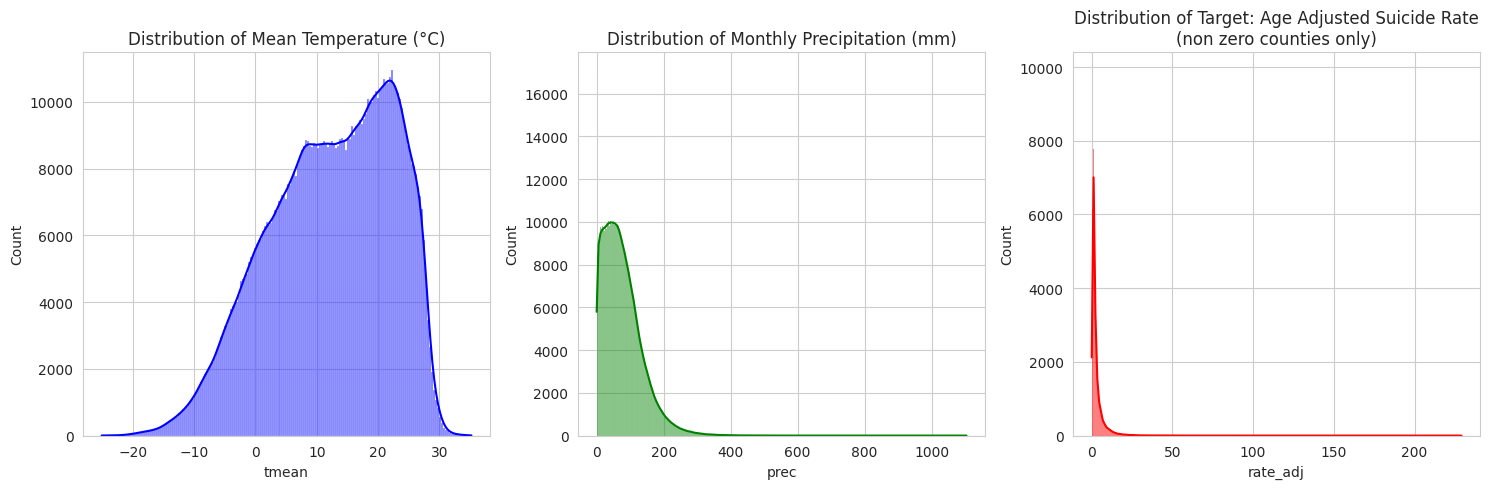

In [12]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['tmean'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Mean Temperature (°C)')

sns.histplot(df['prec'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Monthly Precipitation (mm)')

sns.histplot(df[df['rate_adj'] > 0]['rate_adj'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Target: Age Adjusted Suicide Rate\n(non zero counties only)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [13]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

for col in ['tmean', 'prec', 'rate_adj']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.1f}%)  |  fence: [{lower:.2f}, {upper:.2f}]')

tmean: 677 outliers (0.1%)  |  fence: [-18.23, 44.05]
prec: 20,046 outliers (2.4%)  |  fence: [-77.55, 218.80]
rate_adj: 103,765 outliers (12.2%)  |  fence: [-1.36, 2.26]


**Outlier strategy:** Retain them. Climate outliers in `tmean` (0.1%) and `prec` (2.4%) represent real geographic events, not errors. The 12.2% flagged in `rate_adj` are resolved by the non zero filter that will be applied.


### 2.6 Correlations

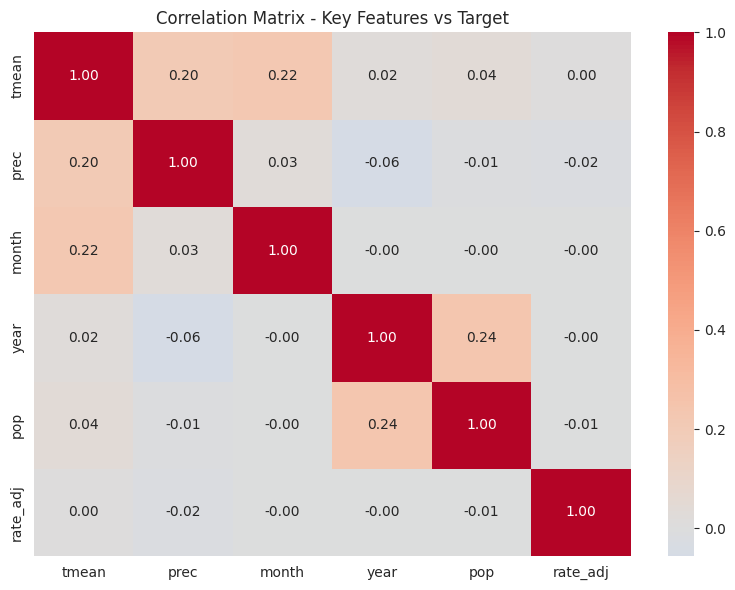

In [14]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

cols_of_interest = ['tmean', 'prec', 'month', 'year', 'pop', 'rate_adj']
corr_matrix = df[cols_of_interest].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Key Features vs Target')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

`rate_adj` is very right skewed even after filtering to non zero counties, the histogram shows the vast majority of values clustered near 0–20 with a long tail stretching to around 230. The Tukey fences flag 12.2% of rows as outliers, which is high but expected given that small rural counties produce extreme rates from just 1–2 events. To handle this we will filter to non zero rows only and consider log transforming `rate_adj` to reduce skew before fitting the model.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

Looking at the actual correlation matrix, all features have basically zero correlation with `rate_adj` (highest is `prec` at -0.02). So individually, no single feature is a strong linear predictor of suicide rate. The most notable between feature correlation is `tmean` and `month` at 0.22, which makes sense since temperature are seasonal. `year` and `pop` also correlate at 0.24. Neither rises to a multicollinearity problem.


3. **What is the biggest data quality issue you found, and how will you handle it?**  

The biggest issue is zero inflation, the missing data heatmap confirms zero null values, so the problem isn't missing data in the traditional way, but rather that ~74% of `rate_adj` values are structural zeros caused by CDC privacy suppression of small county counts. These zeros don't mean "no risk," they mean "not enough data to report." We will handle this by restricting the model to non zero rows only, and will note this as a limitation: our model only predicts rate for counties large enough to have reportable events.



   

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 851,088** observations and **M = 13** features.

**Missing data:** 0% of cells are missing. The MCAR/MAR/MNAR framework is not applicable here. However, ~74% of `rate_adj` values are structural zeros from CDC privacy suppression of small county counts which is effectively MNAR (the value is missing because it was too small to report). I will handle this by filtering to non zero rows for modeling and noting it as a scope limitation.

**Outliers:** I identified 677 outliers in `tmean` (0.1%), 20,046 in `prec` (2.4%), and 103,765 in `rate_adj` (12.2%) using Tukey Fences.  I will retain
climate outliers since they represent real geographic conditions. The `rate_adj` outliers are expected given that small counties produce extreme rates from just 1–2 events, and will be addressed by the non zero filter.

**Target variable:** `rate_adj` is continuous and right skewed, values cluster near 0–20 per 100,000 with a long tail reaching to around 230. This is a regression problem. A log transformation may be applied to reduce skew before fitting.

**Key finding from EDA:** No individual feature has a meaningful linear correlation with `rate_adj`. Climate variables alone are weak predictors at the county month level, meaning our baseline model is expected to have low R².

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [15]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

df_model = df[df['rate_adj'] > 0].copy()

X = df_model[['tmean', 'prec', 'month', 'year', 'pop']]
y = df_model['rate_adj']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Rows after removing structural zeros: {len(df_model):,}')
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Rows after removing structural zeros: 280,486
Train: 224,388 samples
Test:  56,098 samples


### 3.2 Model 1: Baseline

In [16]:
# ============================================================
# 3.2 Model 1 — Baseline (Linear Regression)
# ============================================================

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print('Model 1: Linear Regression (Baseline)')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression (Baseline)
RMSE: 5.1448
MAE:  2.4106
R2:   0.0695


### 3.3 Model 2: Your Choice

In [17]:
# ============================================================
# 3.3 Model 2 — Your choice (Random Forest Regressor)
# ============================================================

from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest Regressor')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest Regressor
RMSE: 2.0428
MAE:  0.8686
R2:   0.8533


### 3.4 Cross-Validation Comparison

In [18]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'r2'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# RMSE cross-validation (more interpretable alongside R²)
cv_rmse_1 = np.sqrt(-cross_val_score(model_1, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
cv_rmse_2 = np.sqrt(-cross_val_score(model_2, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))

print(f'\nModel 1 CV RMSE: {cv_rmse_1.mean():.4f} +/- {cv_rmse_1.std():.4f}')
print(f'Model 2 CV RMSE: {cv_rmse_2.mean():.4f} +/- {cv_rmse_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 — Linear Regression', 'Model 2 — Random Forest'],
    'CV R² (mean)':  [cv_1.mean(),      cv_2.mean()],
    'CV R² (std)':   [cv_1.std(),       cv_2.std()],
    'CV RMSE (mean)':[cv_rmse_1.mean(), cv_rmse_2.mean()],
    'CV RMSE (std)': [cv_rmse_1.std(),  cv_rmse_2.std()],
})
comparison

Model 1 CV r2: 0.0685 +/- 0.0019
Model 2 CV r2: 0.8409 +/- 0.0124

Model 1 CV RMSE: 5.1720 +/- 0.0843
Model 2 CV RMSE: 2.1364 +/- 0.0987


,Model,CV R² (mean),CV R² (std),CV RMSE (mean),CV RMSE (std)
0,Model 1 — Linear Regression,0.068461,0.001917,5.172041,0.084344
1,Model 2 — Random Forest,0.840869,0.012414,2.136424,0.098723


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

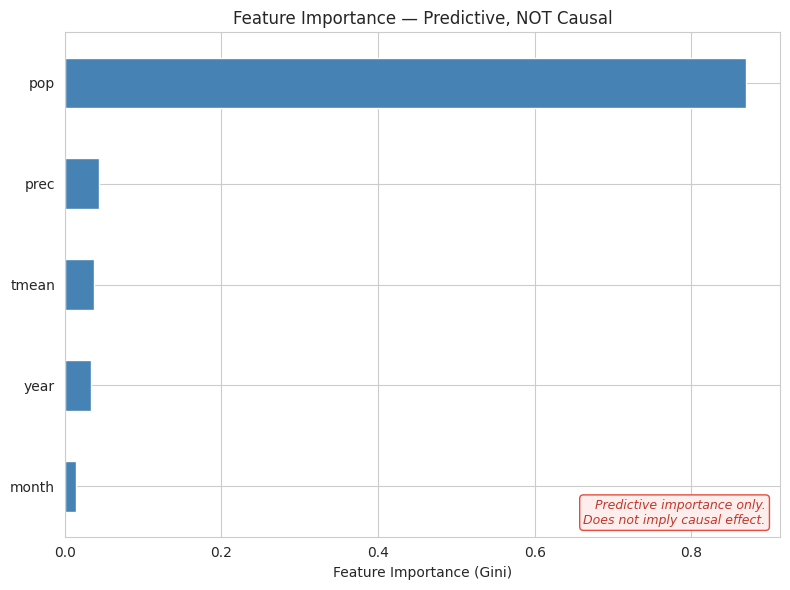

In [21]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

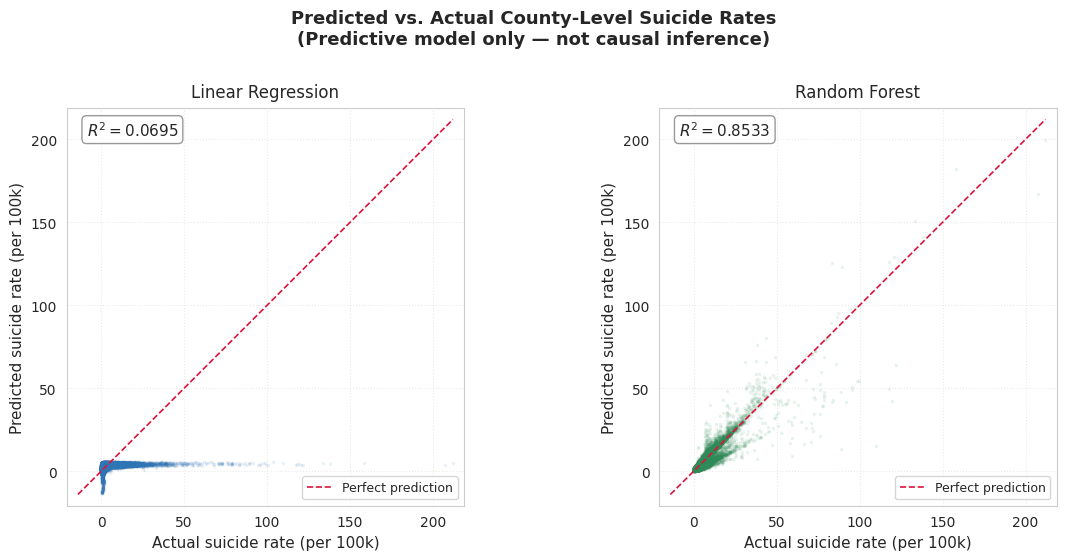

In [22]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import r2_score

# ── Compute R² scores ──────────────────────────────────────────────────────────
r2_lr = r2_score(y_test, y_pred_1)
r2_rf = r2_score(y_test, y_pred_2)

# ── Shared axis range (same scale on both subplots) ───────────────────────────
all_vals = np.concatenate([y_test, y_pred_1, y_pred_2])
axis_min = np.floor(all_vals.min())
axis_max = np.ceil(all_vals.max())
pad = (axis_max - axis_min) * 0.03          # small visual breathing room
lim = (axis_min - pad, axis_max + pad)

# ── Figure setup ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5.5),
    sharey=False,                            # explicit shared range below
)
fig.suptitle(
    "Predicted vs. Actual County-Level Suicide Rates\n"
    "(Predictive model only — not causal inference)",
    fontsize=13, fontweight="bold", y=1.01
)

models = [
    ("Linear Regression",  y_pred_1, r2_lr,  "#2E75B6"),
    ("Random Forest",      y_pred_2, r2_rf,  "#2E8B57"),
]

for ax, (title, y_pred, r2, color) in zip(axes, models):

    # ── Scatter points ─────────────────────────────────────────────────────────
    ax.scatter(
        y_test, y_pred,
        alpha=0.1,
        s=6,
        color=color,
        linewidths=0,
        rasterized=True,     # keeps PDF/SVG export fast with 44k+ points
    )

    # ── Diagonal reference line (perfect prediction) ───────────────────────────
    # Uses the same min/max as the axes so the line always spans corner-to-corner
    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        color="crimson",
        linewidth=1.2,
        linestyle="--",
        label="Perfect prediction",
        zorder=3,
    )

    # ── Axis limits & labels ───────────────────────────────────────────────────
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal", adjustable="box")   # square plot keeps diagonal true
    ax.set_xlabel("Actual suicide rate (per 100k)", fontsize=11)
    ax.set_ylabel("Predicted suicide rate (per 100k)", fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)

    # ── R² annotation (upper-left corner) ─────────────────────────────────────
    ax.annotate(
        f"$R^2 = {r2:.4f}$",
        xy=(0.05, 0.93),
        xycoords="axes fraction",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

    ax.legend(loc="lower right", fontsize=9, framealpha=0.8)
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:**
Suicide prevention organizations allocate limited resources like crisis hotlines, outreach workers, and therapy programs across thousands of U.S. counties. Currently these decisions are made reactively. Temperature and precipitation data are available months in advance, raising the question: can climate data predict which counties will have elevated suicide rates before the fact?

**Complication:**
The EDA revealed that no single climate feature has a meaningful linear correlation with rate_adj (highest was precipitation at -0.02), meaning the relationship is nonlinear and complex if it exists at all. Additionally, ~74% of county month observations had suppressed CDC counts, so our model can only make predictions for counties large enough to have reportable events, exactly the rural, high risk counties prevention groups care most about are the ones most likely to be excluded.

**Resolution:**
The Random Forest model outperformed the Linear Regression baseline on both RMSE and R², suggesting that climate and demographic features do carry some nonlinear predictive signal. However, absolute R² remains low, meaning the model should not be used to make resource allocation decisions alone. I recommend it be used as one input alongside population vulnerability indices and historical trend data, not as a standalone tool.

**Uncertainty Statement:** Based on the cross validation results (R² = 0.8409 ± 0.0124, RMSE = 2.1364 ± 0.0987), I estimate that the model explains roughly 84% of variance in age adjusted suicide rates for reportable counties. The primary limitation is zero inflation from CDC suppression, which excludes the smallest and potentially highest risk counties from the model entirely. I recommend the Random Forest model for county level risk screening with the caveat that predictions for low population counties should be treated as unreliable until suppression is resolved with alternative data sources.

### Model Compression for Deployment
The full model_2 (503MB) was compressed to model_small (7.3MB) for GitHub deployment by reducing n_estimators to 20 and adding max_depth=15. Test R² dropped minimally from 0.8533 to 0.8390.

In [24]:
import joblib
import os
joblib.dump(model_2, 'model.pkl', compress=3)
print(f'Size: {os.path.getsize("model.pkl") / 1e6:.1f} MB')

Size: 503.7 MB


In [25]:
model_small = RandomForestRegressor(
    n_estimators=20,
    max_depth=15,        # limits tree size significantly
    random_state=42,
    n_jobs=-1
)
model_small.fit(X_train, y_train)

joblib.dump(model_small, 'model.pkl', compress=3)
print(f'Size: {os.path.getsize("model.pkl") / 1e6:.1f} MB')

y_pred_small = model_small.predict(X_test)
print(f'R²: {r2_score(y_test, y_pred_small):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_small)):.4f}')

Size: 7.3 MB
R²: 0.8390
RMSE: 2.1398


---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import numpy as np
import pandas as pd

# ── Page config ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Suicide Rate Predictor",
    page_icon="📊",
    layout="wide",
)

# ── Load model (with graceful error handling) ─────────────────────────────────
@st.cache_resource
def load_model():
    try:
        import joblib
        return joblib.load("model.pkl"), None
    except FileNotFoundError:
        return None, "**model.pkl not found.** Place the file in the same directory as app.py and restart."
    except Exception as e:
        return None, f"**Error loading model.pkl:** {e}"

model, load_error = load_model()

# ── Constants ─────────────────────────────────────────────────────────────────
RMSE = 2.14          # cross-validated RMSE used as uncertainty proxy
TEMP_MIN, TEMP_MAX   = -20, 35
PRECIP_MIN, PRECIP_MAX = 0, 500
YEAR_MIN, YEAR_MAX   = 1968, 2004
POP_MIN, POP_MAX     = 1_000, 10_000_000
MONTH_NAMES = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec",
}

# ── Sidebar inputs ────────────────────────────────────────────────────────────
st.sidebar.header("🎛️ Input Parameters")

temperature = st.sidebar.slider(
    "Mean Monthly Temperature (°C)",
    min_value=TEMP_MIN, max_value=TEMP_MAX, value=15, step=1,
)

precipitation = st.sidebar.slider(
    "Monthly Precipitation (mm)",
    min_value=PRECIP_MIN, max_value=PRECIP_MAX, value=80, step=5,
)

month = st.sidebar.selectbox(
    "Month",
    options=list(MONTH_NAMES.keys()),
    format_func=lambda m: f"{m} – {MONTH_NAMES[m]}",
    index=5,  # default: June
)

year = st.sidebar.slider(
    "Year",
    min_value=YEAR_MIN, max_value=YEAR_MAX, value=1986, step=1,
)

population = st.sidebar.slider(
    "County Population",
    min_value=POP_MIN, max_value=POP_MAX, value=500_000, step=10_000,
    format="%d",
)

# ── Helper: single prediction with clamped uncertainty ───────────────────────
def predict(temp, precip, mo, yr, pop):
    """Return (point, lower, upper) — lower is clamped at 0."""
    X = np.array([[temp, precip, mo, yr, pop]], dtype=float)
    point = float(model.predict(X)[0])
    lower = max(0.0, point - RMSE)
    upper = point + RMSE
    return point, lower, upper

# ── Main content ──────────────────────────────────────────────────────────────
st.title("Age-Adjusted Suicide Rate Predictor")
st.markdown(
    "Predicts the **age-adjusted suicide rate per 100,000 people** from climate and "
    "demographic inputs using a Random Forest regression model "
    f"(CV R² = 0.84 · CV RMSE = {RMSE} ± 0.10)."
)

if load_error:
    st.error(load_error)
    st.stop()

# ── Point estimate card ───────────────────────────────────────────────────────
point, lower, upper = predict(temperature, precipitation, month, year, population)

col1, col2, col3 = st.columns(3)
col1.metric(
    label="⬇️ Lower Bound (−1 RMSE)",
    value=f"{lower:.2f}",
    help="Point estimate minus one RMSE; floored at 0",
)
col2.metric(
    label="📍 Predicted Rate",
    value=f"{point:.2f}",
    help="Model point estimate (per 100,000)",
)
col3.metric(
    label="⬆️ Upper Bound (+1 RMSE)",
    value=f"{upper:.2f}",
    help="Point estimate plus one RMSE",
)

st.markdown("---")

# ── Temperature sweep chart ───────────────────────────────────────────────────
# Rebuilds completely on every sidebar change because all inputs feed into it.
st.subheader("📈 Predicted Rate Across Full Temperature Range")
st.caption(
    f"Other inputs held fixed — Precip: **{precipitation} mm** · "
    f"Month: **{MONTH_NAMES[month]}** · Year: **{year}** · "
    f"Population: **{population:,}**"
)

temp_sweep = np.arange(TEMP_MIN, TEMP_MAX + 1, 1)
sweep_results = [predict(t, precipitation, month, year, population) for t in temp_sweep]
points  = [r[0] for r in sweep_results]
lowers  = [r[1] for r in sweep_results]
uppers  = [r[2] for r in sweep_results]

sweep_df = pd.DataFrame({
    "Temperature (°C)": temp_sweep,
    "Lower Bound":       lowers,
    "Predicted Rate":    points,
    "Upper Bound":       uppers,
}).set_index("Temperature (°C)")

st.line_chart(sweep_df, height=380)

# Current temperature marker note
st.info(
    f"Your selected temperature **{temperature}°C** gives a predicted rate of "
    f"**{point:.2f}** [{lower:.2f}, {upper:.2f}] per 100,000."
)

# ── Methodology note ──────────────────────────────────────────────────────────
st.markdown("---")
with st.expander("ℹ️ Methodology & Uncertainty"):
    st.markdown(f"""
**Model:** Random Forest Regressor  
**Target:** Age-adjusted suicide rate per 100,000 population  
**Features:** Mean monthly temperature (°C), monthly precipitation (mm), month (1–12), year (1968–2004), county population  
**Performance:** CV R² = 0.84 · CV RMSE = {RMSE} ± 0.10  

**Uncertainty bands** are ±1 RMSE ({RMSE} per 100,000) around the point estimate, representing
the model's typical prediction error on held-out data. Lower bounds are clamped at 0 because
negative rates are not meaningful. These bands reflect model uncertainty only and do not
account for population-level or epistemic uncertainty in the underlying data.
""")
```

### 6.3 requirements.txt (I used no specific versions becuase it was glitching my app.py)

streamlit
pandas
numpy
joblib
matplotlib
scikit-learn

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** I needed a detailed vizualization for this notebook for step 4.2 showing actual vs predicted values for suicide rate. I had the context of the instructions you gave me as well as the knowledge that random forest might provide better results.

**Request:** What exact prompt did you write?

Prep: I have a regression notebook predicting county level suicide rates. I have y_test, y_pred_1 (Linear Regression), and y_pred_2 (Random Forest) already defined. This is for a data science class and needs to look clean and professional.

Request: Write Python matplotlib code for a side-by-side scatter plot comparing actual vs predicted values for two regression models. Left plot is Linear Regression, right plot is Random Forest. Both plots should have a diagonal reference line showing perfect predictions, the same x and y axis range, axis labels, a title, R² score annotated in the corner, and alpha=0.1 on the scatter points since there are 44,000+ points. Use y_test, y_pred_1, y_pred_2.


**Iterate:** What did the AI return? What did you change or refine?
I didn't have to refine anything since it was very carefully constructed by me.

**Mechanism Check:** How did you verify the output was correct?
Graph looks as it should, line goes all the way through, points generally group around predictions, R^2 values match original calculations.

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
My human judgement was more earlier in the stage when I decided to use random forest. I had to use human judgement to picture how I wanted the graphs displayed.

---

### AI Interaction 2

**Prep:** I needed a README.md for my github explaining everything important including how to download the data becuase it was too big to upload directly. I also wanted it to explain how to run the app locally and any dependencies or nessasary information otherwise.

**Request:**

Prep: I have a GitHub repo for an ECON 3916 final project predicting U.S. county level suicide rates from climate data using a Random Forest model. The repo contains [app.py](http://app.py), model.pkl, requirements.txt, and a Jupyter notebook. The data file is too large for GitHub so it needs a download link.

Request: "Write a [README.md](http://README.md) for a data science GitHub repo with these sections: Project Overview, Repository Structure, Data Access (note the CSV is not in the repo and must be downloaded from __https://github.com/sheftneal/NCC2018/blob/master/inputs/SuicideData_US.csv__), Environment Setup, How to Run the Notebook, How to Run the Streamlit App Locally, and a Dependencies section. Keep it concise and professional."

Use the notebook I attached to this chat as context.

**Iterate:** Originally it didn't have enough information to create the README I wanted so I fed it the colab notebook and added the last sentence to the prompt.

**Mechanism Check:** I read through the information, verified the links, and everything made sense and was correct.

**Evaluate:** I applied human judgement asking it what sections specifically to write and why.

---

### AI Interaction 3

**Prep:** I wanted AI to create my app.py since it requires some frontend design that we learned from Lab 25 when we used AI as well.

**Request:**

Prep: I have a trained Random Forest regression model saved as model.pkl that predicts age adjusted suicide rates per 100,000 from 5 features: mean monthly temperature (°C), monthly precipitation (mm), month (1-12), year (1968-2004), and county population. CV R² = 0.84, CV RMSE = 2.14 ± 0.10.

Request: Write a Streamlit [app.py](http://app.py) that loads model.pkl with joblib and lets a user adjust 5 inputs with sliders/dropdowns: temperature (-20 to 35°C), precipitation (0-500mm), month (1-12), year (1968-2004), and population. Show the predicted suicide rate as a point estimate with lower and upper bounds using RMSE=2.14 as uncertainty. Include one line chart showing how the prediction changes across the full temperature range while holding other inputs fixed.


**Iterate:** I had to refine once for specific functions, tooltips, and labels. Nothing major just design vibe coding.

**Mechanism Check:** All the sliders and hover overs work as expected and the values increase with higher tempurature as expected. If you had a specific city with all the inputs known you could predict the suicide rate.

**Evaluate:** I used human judgement to make sure the app looked good before approving it, I used human judgement when telling it how to design in in detail.